### precompute image latents

Here we are passing all images of dataset through flux.2 vae encoder and save latents.

In [1]:
from diffusers.models import AutoencoderKLFlux2
import torch
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from torchvision import transforms
import time
import json
import tqdm

device = "cuda"

In [ ]:
vae = AutoencoderKLFlux2.from_pretrained("../../FLUX.2-klein-4B/vae", device=device).to(device)

In [ ]:
with open("../../coco2017/annotations/captions_train2017.json") as f:
    data = json.load(f)

In [4]:
data["annotations"][0]

{'image_id': 203564,
 'id': 37,
 'caption': 'A bicycle replica with a clock as the front wheel.'}

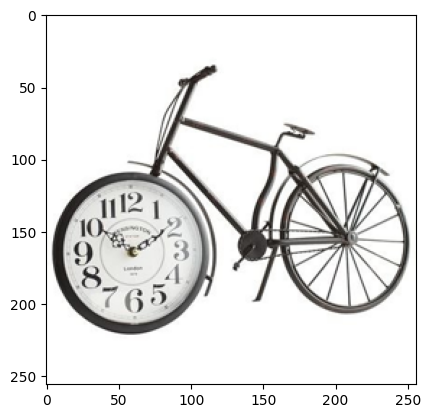

torch.Size([1, 3, 256, 256])
tensor(0.0235, device='cuda:0') tensor(1., device='cuda:0')


In [ ]:
transform = transforms.Compose([transforms.ToTensor()])
img = Image.open(f"../../coco2017/train2017/{str(203564).rjust(12, "0")}.jpg").convert("RGB")
img = img.resize((256, 256))
plt.imshow(img)
plt.show()

img_tensor = transform(img)
img_tensor = img_tensor.unsqueeze(0).cuda()
print(img_tensor.shape)
print(img_tensor.min(), img_tensor.max())

In [ ]:
def process_batch(image_ids):
    img_tensors = []
    for image_id in image_ids:
        img = Image.open(f"../../coco2017/train2017/{str(image_id).rjust(12, "0")}.jpg").convert("RGB")
        img = img.resize((256, 256))
        img_tensor = transform(img)
        img_tensor = img_tensor.unsqueeze(0).cuda()
        img_tensors.append(img_tensor)
    
    all_tensor = torch.cat(img_tensors, dim=0) # [batch_size, 3, 256, 256]

    with torch.no_grad():
        all_tensor_norm = (all_tensor - 0.5) * 2
        all_latent = vae.encode(all_tensor_norm).latent_dist.mean # [batch_size, 32, 32, 32]

    return all_latent.to("cpu", torch.float16)

In [ ]:
batch_size = 8

num_samples = 21220

latents_array = torch.empty(
    (num_samples, 32, 32, 32),
    dtype=torch.float16,
)

idx = 0
batch = []

for annotation in tqdm.tqdm(data["annotations"]):
    image_id = annotation["image_id"]
    batch.append(image_id)
    if len(batch) == batch_size:
        latents_batch = process_batch(batch)
        n = len(latents_batch)
        latents_array[idx:idx+n] = latents_batch
        idx += n
        batch = []

if len(batch) > 0:
    latents_batch = process_batch(batch)
    n = len(latents_batch)
    latents_array[idx:idx+n] = latents_batch
    idx += n
    batch = []

100%|██████████| 591753/591753 [02:43<00:00, 3611.54it/s] 


In [ ]:
torch.save(latents_array, "../../precomputes/latents_256x256.pt")

In [ ]:
latents_array = torch.load("../../precomputes/latents_256x256.pt")

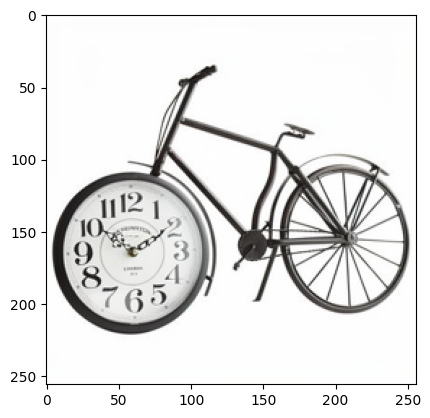

In [10]:
latent = latents_array[:1, ...].to(device).float()

with torch.no_grad():
    reconstructed = (vae.decode(latent).sample + 1.0 ) / 2.0

reconstructed = reconstructed.squeeze(0).permute((1, 2, 0)).cpu().numpy()
reconstructed = np.clip(reconstructed, 0, 1)

plt.imshow(reconstructed)
plt.show()

In [11]:
590000 * 32 * 32 * 32 * 2 / 1024 / 1024 / 1024

36.0107421875